## Validate entrenchment sites using raw count data
This notebook attempts to validate the findings of entrenchment of specific sites (38, 55 etc) between v families or v genes using DASM using raw counts.
rates_analysis_producitve_non_productive was lacking many entrenched data points because they have barely been observed in the non productive data.
To deal with this limitation, we ran a similar analysis, but instead of calculating the expected counts from the data, we will take it use thrifty to calculate, and compare to the observed counts in the productive data. 
We compare counts directly and not rates because the pcp dataset is the same, and thus has the same branch lengths and they will cancel each other out.


For productive data, observed counts (code duplicated from rates_analysis_productive_non_productive):
- Counted as mutations away from the germline amino acid for the v gene. Thus, rates are only calculated for v-gene encoded sites. 
- Calculated per v_family+site+parent_aa+child_aa, to compare to DASM.

For expected counts:
- we run thrifty on the same dataset, so branch lengths will be the same as the productive counts and counts can be compared directly.
- Thrifty gives out a rate for any substitution and a conditional substitution probability (csp). I use branch length (which can be synonymous mutation frequncy or total mutation frequency, total mutation frequency seem to work better in this case) to calculate the general substation probability from the rate, and multiply by the csp to get the substitution probability per target amino acid for every branch/pcp. I then sum over those per v_family+site+parent_aa+target_aa to get the expected counts. 


The calculation is performed on pcps and relies on previous code:
- For observed counts, site_sub_probs_df from OEPlotter is utilized - probabilities are not used of course, only the occurences of mutations on a pcp.
- For expected counts, we adapted code from dnsm-experiments-1/dnsmex/neutral_mutability.py. That code provides the mutability per a constant branch length, and here we added the option for a separate branch length calculation - synonymous mutation frequency or total mutaiton frequency.

Entrenched sites, aas and v families are loaded from _output/entrenchment_analysis made in vj_families_dasm.

Results:
- Count ratios calculated align nicely with DASM.
- Entrenched sites and substitutions also align nicely. Not all substitutions can be validated with this approach, but most of them can.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import glob

from netam.sequences import AA_STR_SORTED, CODONS, translate_codon
from utils import sort_antibody_sites, add_germline_information, load_and_process_dnsm_data, load_and_process_dasm_data
from run_thrifty_neutral import CachedNeutralMutationProbability

from rates_analysis_util import compare_mutation_rates_on_different_backgrounds_for_all_sites

figures_dir = 'figures/'


In [ ]:
DATASET = 'v1rodriguez'
#DATASET = 'v1jaffeCC'

#numbering_scheme = 'imgt'
numbering_scheme = 'chothia'

In [ ]:
## load and prepare data for **observed** mutation counts


def add_mutation_counts_per_branch_for_branch_length(site_sub_probs_df_germline, pcp_df, remove_leaves=True):
    # add columns for synonymous and nonsynonymous
    # nucleotide mutations frequency per branch as an alternative to branch length
    site_sub_probs_df_germline['seq_nuc_length'] = site_sub_probs_df_germline.groupby('pcp_index').transform('size') * 3  # nucleotide length

    site_sub_probs_df_germline['nucleotide_mutation_count'] = site_sub_probs_df_germline.apply(lambda row: sum(c1 != c2 for c1, c2 in zip(row['child_codon'], row['parent_codon'])), axis=1)
    site_sub_probs_df_germline['mutation'] = site_sub_probs_df_germline['parent_aa'] != site_sub_probs_df_germline['child_aa']

    site_sub_probs_df_germline['synonymous_nucleotide_mutation_count'] = np.where(
        site_sub_probs_df_germline['mutation'] == False,
        site_sub_probs_df_germline['nucleotide_mutation_count'],
        0)
    site_sub_probs_df_germline['nonsynonymous_nucleotide_mutation_count'] = np.where(
        site_sub_probs_df_germline['mutation'] == True,
        site_sub_probs_df_germline['nucleotide_mutation_count'],
        0)

    site_sub_probs_df_germline['synonymous_mutations_per_branch'] = site_sub_probs_df_germline.groupby('pcp_index')['synonymous_nucleotide_mutation_count'].transform('sum')
    site_sub_probs_df_germline['nonsynonymous_mutations_per_branch'] = site_sub_probs_df_germline.groupby('pcp_index')['nonsynonymous_nucleotide_mutation_count'].transform('sum')
    site_sub_probs_df_germline['total_mutations_per_branch'] = site_sub_probs_df_germline['nonsynonymous_mutations_per_branch'] + site_sub_probs_df_germline['synonymous_mutations_per_branch']  # should equal total mutations per branch

    site_sub_probs_df_germline['synonymous_mutation_freq_branch'] = site_sub_probs_df_germline['synonymous_mutations_per_branch'] / site_sub_probs_df_germline['seq_nuc_length']
    site_sub_probs_df_germline['nonsynonymous_mutation_freq_branch'] = site_sub_probs_df_germline['nonsynonymous_mutations_per_branch'] / site_sub_probs_df_germline['seq_nuc_length']
    site_sub_probs_df_germline['total_mutation_freq_branch'] = site_sub_probs_df_germline['total_mutations_per_branch'] / site_sub_probs_df_germline['seq_nuc_length']
        
    if remove_leaves:
        print("Removing leaf nodes from the analysis")
        pcp_df_for_merge = pcp_df.copy()
        pcp_df_for_merge = pcp_df_for_merge[[ 'child_is_leaf']]
        pcp_df_for_merge['pcp_index'] = pcp_df_for_merge.index
        site_sub_probs_df_germline = pd.merge(site_sub_probs_df_germline, pcp_df_for_merge, on='pcp_index', how='inner')
        site_sub_probs_df_germline = site_sub_probs_df_germline[~site_sub_probs_df_germline['child_is_leaf']]

    return site_sub_probs_df_germline


site_sub_probs_df_germline_total, total_pcp_df = load_and_process_dnsm_data(model_name = "dnsm_1m-v1jaffe+v1tang-joint", dataset_name=DATASET, numbering_scheme=numbering_scheme)
site_sub_probs_df_germline_total = add_mutation_counts_per_branch_for_branch_length(site_sub_probs_df_germline_total, total_pcp_df)


Removing leaf nodes from the analysis


In [ ]:
## calculate observed mutation counts
## branch length method doesn't actually matter here because we are using the ratio of observed to expected counts (same pcp dataset, so same branch lengths will cancel out anyway)

output_dirs = ['_ignore/observed_counts_from_productive']
for dir in output_dirs:
    if not os.path.exists(dir):
        os.mkdir(dir)

branch_length_method = 'total_mutation_freq_branch'
output_base_path = f'_ignore/observed_counts_from_productive/observed_mutation_rates_{DATASET}_bl_{branch_length_method}_{numbering_scheme}'

# check if output file already exists
if not os.path.exists(f'{output_base_path}_per_aa_mutation_rates.csv'):
    compare_mutation_rates_on_different_backgrounds_for_all_sites(site_sub_probs_df_germline_total, output_base_path, branch_length_method=branch_length_method)

observed_aa_df = pd.read_csv(f'{output_base_path}_per_aa_mutation_rates.csv', dtype={'site':str})
observed_aa_df = observed_aa_df.rename(columns={'mutation_acquired':'observed_counts', 'mutcount_length':'mutcount_length_observed'}).drop(columns=['rate_mutcount'])
observed_aa_df

,v_family,site,parent_aa,child_aa,mutcount_length_observed,observed_counts
0,IGHV1,1,Q,A,68.147098,0
1,IGHV1,1,Q,C,68.147098,0
2,IGHV1,1,Q,D,68.147098,0
3,IGHV1,1,Q,E,68.147098,4
4,IGHV1,1,Q,F,68.147098,0
...,...,...,...,...,...,...
10255,IGHV4,94,R,S,66.663274,8
10256,IGHV4,94,R,T,66.663274,13
10257,IGHV4,94,R,V,66.663274,0
10258,IGHV4,94,R,W,66.663274,0


In [ ]:
# load thrifty neutral model **expected** mutation counts

neutral_probabilties = CachedNeutralMutationProbability(DATASET, branch_length_method='from_total_mutations', numbering_scheme=numbering_scheme)


# add germline information to all dataframes
neutral_probabilties.aa_neutral_df = add_germline_information(neutral_probabilties.pcp_df, neutral_probabilties.aa_neutral_df, numbering_scheme=numbering_scheme)
neutral_probabilties.aa_to_any_neutral_df = add_germline_information(neutral_probabilties.pcp_df, neutral_probabilties.aa_to_any_neutral_df, numbering_scheme=numbering_scheme)
neutral_probabilties.codon_neutral_df = add_germline_information(neutral_probabilties.pcp_df, neutral_probabilties.codon_neutral_df, numbering_scheme=numbering_scheme)
neutral_probabilties.codon_to_any_neutral_df = add_germline_information(neutral_probabilties.pcp_df, neutral_probabilties.codon_to_any_neutral_df, numbering_scheme=numbering_scheme)

# probabilities sum to counts
expected_aa_df = neutral_probabilties.aa_neutral_df[neutral_probabilties.aa_neutral_df.is_germline_codon == True].groupby(['site', 'current_aa', 'v_family', 'transition_aa']).substitution_probability.sum().reset_index()
expected_aa_df


Loading NeutralMutationProbability data from gzip cache [method: from_total_mutations]...
✓ Loaded from gzip cache:
  - Nucleotide DataFrame: 31,773,960 rows
  - Amino Acid DataFrame: 18,733,551 rows
  - Amino Acid to Any DataFrame: 2,647,830 rows
  - Codon DataFrame: 26,478,300 rows
  - Codon to Any DataFrame: 2,647,830 rows
  - PCP DataFrame: 21,752 rows


,site,current_aa,v_family,transition_aa,substitution_probability
0,1,E,IGHV1,*,0.368789
1,1,E,IGHV1,A,0.266311
2,1,E,IGHV1,D,0.786468
3,1,E,IGHV1,E,0.666444
4,1,E,IGHV1,G,0.478161
...,...,...,...,...,...
7128,94,T,IGHV3,K,1.313462
7129,94,T,IGHV3,P,1.783286
7130,94,T,IGHV3,R,1.714679
7131,94,T,IGHV3,S,1.609605


<Axes: >

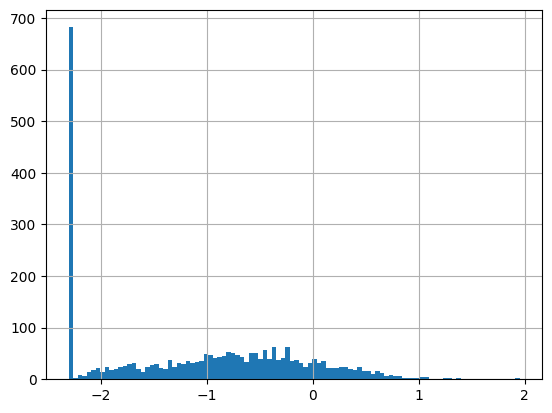

In [ ]:
# merge observed and expected counts - ratio should be the selection factor.


merge_counts = pd.merge(expected_aa_df.rename(columns={'current_aa':'parent_aa', 'transition_aa':'child_aa', 'substitution_probability':'expected_counts'}), observed_aa_df, on=['v_family', 'site', 'parent_aa', 'child_aa'])
merge_counts['ratio'] = merge_counts['observed_counts'] / merge_counts['expected_counts']
merge_counts['log_ratio'] = np.log(merge_counts['ratio'] + 1e-1)

merge_counts[merge_counts.expected_counts >= 1].log_ratio.hist(bins=100)



## load entrenches sites identified by DASM analysis

We separate sites into two types of evolutionarily constrained sites:
- Within v family entrenched sites
- Between v-family entrenched sites

Here we plot both types together, since we just want to make sure our entrenched sites are not edge cases with low counts.

In [ ]:
#Load entrenched sites, "within" files and "vs" files separately
within_dfs = []
vs_dfs = []

within_files = glob.glob(f'_output/entrenchment_analysis/{numbering_scheme}/entrenched_aa_sites*within*.csv')
vs_files = glob.glob(f'_output/entrenchment_analysis/{numbering_scheme}/entrenched_aa_sites*vs*.csv')


for f in within_files:
    df = pd.read_csv(f, dtype={'site':str})
    within_dfs.append(df)
for f in vs_files:
    df = pd.read_csv(f, dtype={'site':str})
    vs_dfs.append(df)

within_dfs = pd.concat(within_dfs, ignore_index=True)
vs_dfs = pd.concat(vs_dfs, ignore_index=True)


within_sites = within_dfs[['site', 'v_family']].drop_duplicates()
vs_sites = vs_dfs[['site', 'v_family']].drop_duplicates()
within_sites_aas = within_dfs[['site', 'v_family','amino_acid', 'target_amino_acid']].drop_duplicates()
vs_sites_aas = vs_dfs[['site', 'v_family','amino_acid', 'target_amino_acid']].drop_duplicates()


entrenched_sites = pd.concat([within_sites, vs_sites]).drop_duplicates()
entrenched_sites_aas = pd.concat([within_sites_aas, vs_sites_aas]).drop_duplicates()

# Convert to categorical with proper antibody numbering order
entrenched_sites['site'] = pd.Categorical(entrenched_sites['site'], categories=sort_antibody_sites(entrenched_sites['site'].unique()), ordered=True)
entrenched_sites_aas['site'] = pd.Categorical(entrenched_sites_aas['site'], categories=sort_antibody_sites(entrenched_sites_aas['site'].unique()), ordered=True)

# NOW sort using the categorical order
entrenched_sites = entrenched_sites.sort_values(['site', 'v_family'])
entrenched_sites_aas = entrenched_sites_aas.sort_values(['site', 'v_family', 'amino_acid', 'target_amino_acid'])

print(len(entrenched_sites))
print(len(entrenched_sites_aas))


##### pairwise comparisons
pairwise_files = glob.glob(f'_output/entrenchment_analysis/{numbering_scheme}/comparison*vs*.csv')
pairwise_df_dict = {}
for f in pairwise_files:
    pairwise_df_dict[f.split('/')[-1].replace('comparison_', '').replace('.csv', '')] = pd.read_csv(f, dtype={'site':str})




###### Create consistent color palette for entrenched sites
# Get all unique sites from your entrenched data
all_entrenched_sites = sort_antibody_sites(entrenched_sites_aas['site'].unique())

# Create the full palette
full_palette = sns.color_palette("tab20") + sns.color_palette("tab20b")[:5]

# Create a dictionary mapping each site to its color
SITE_COLOR_MAP = {str(site): full_palette[i] for i, site in enumerate(all_entrenched_sites)}

print(f"Created color mapping for {len(SITE_COLOR_MAP)} sites")


57
133
Created color mapping for 24 sites


## Compare rate ratio to DASM

In [ ]:
### compare to DASM

dataset_name = "v1rodriguez"
model_name = "dasm_4m-v1jaffeCC+v1tangCC-joint"

_, _, aa_site_subs_selection_df_germline = load_and_process_dasm_data(model_name=model_name, dataset_name=dataset_name, numbering_scheme=numbering_scheme)

dasm_summarized = aa_site_subs_selection_df_germline[aa_site_subs_selection_df_germline.is_germline_aa == True].groupby(['v_family', 'site', 'parent_aa', 'selection_factor_target_aa']).selection_factor.median().reset_index()


Adding one_mutation_away column: 100%|██████████| 52956600/52956600 [04:06<00:00, 214983.18it/s]


In [ ]:

def plot_dasm_vs_rates_comparison(compare_dasm_rates, entrenched_sites_aas, savefig_prefix=None, title_extra=''):
    # Calculate regression statistics
    x = compare_dasm_rates['log_ratio']
    y = compare_dasm_rates['log_selection_factor']

    # Remove any NaN values for regression calculation
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[mask]
    y_clean = y[mask]

    # Calculate linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
    r_squared = r_value ** 2
    n = len(x_clean)


    # Create the plot
    fig, ax = plt.subplots(figsize=(7, 6))

    # Plot regular points in blue
    sns.scatterplot(data=compare_dasm_rates,
                    x='log_ratio', y='log_selection_factor',
                    color='grey', alpha=0.3, label='Other sites')

    # filter entrenched data
    entrenched_compare_rates_dasm = pd.merge(entrenched_sites_aas.rename(columns={'amino_acid':'parent_aa', 'target_amino_acid':'child_aa'}), compare_dasm_rates, on=['site', 'v_family', 'parent_aa', 'child_aa'], how='inner')
    print(f"Plotting {len(entrenched_compare_rates_dasm)} entrenched points")
    # print which points were not found in the compare_dasm_rates
    not_found = pd.merge(entrenched_sites_aas.rename(columns={'amino_acid':'parent_aa', 'target_amino_acid':'child_aa'}), compare_dasm_rates, on=['site', 'v_family', 'parent_aa', 'child_aa'], how='outer', indicator=True)
    not_found = not_found[not_found['_merge'] == 'left_only']
    if len(not_found) > 0:
        print("The following entrenched points were not found in the comparison data:")
        print(not_found[['site', 'v_family', 'parent_aa', 'child_aa']])
    # plot entrenched points in color
    entrenched_compare_rates_dasm['site'] = entrenched_compare_rates_dasm['site'].astype(str)
    sns.scatterplot(data=entrenched_compare_rates_dasm,
                    x='log_ratio', y='log_selection_factor',
                    s=90, hue='site', style='v_family', palette=SITE_COLOR_MAP)

    # Add the regression line
    sns.regplot(data=compare_dasm_rates, x='log_ratio', y='log_selection_factor',
                scatter=False, line_kws={'linestyle': '--', 'color': 'black'})

    ax.axvline(0, color='black', linestyle=':', linewidth=1)
    ax.axhline(0, color='black', linestyle=':', linewidth=1)

    # Add legend
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    plt.xlabel('Observed Rate / Expected Rate (log)')
    plt.ylabel('DASM Selection Factor (log)')

    # Format the equation and R² for the title
    if intercept >= 0:
        equation = f'y = {slope:.3f}x + {intercept:.3f}'
    else:
        equation = f'y = {slope:.3f}x - {abs(intercept):.3f}'

    title = f'Comparison of Observed/Expected Counts Ratio vs DASM Selection Factor\nObserved from productive sequences, Expected from Thrifty model\n{equation}, R² = {r_squared:.3f}, n = {n}\n{title_extra}'

    plt.title(title)

    plt.tight_layout()
    plt.show()
    if savefig_prefix:
        fig.savefig(f'figures/{savefig_prefix}validation_dasm_vs_rates_thrifty_comparison_all.pdf', dpi=800)



def plot_rates_pairwise_analysis(compare_dasm_rates, pairwise_df_dict, savefig_prefix=None, title_extra=''):
    fig, axes = plt.subplots(2, 3, figsize=(18, 7))
    fig.subplots_adjust(hspace=0.5, wspace=0.3, right=0.85, top=0.8)  # Make room on the right
    axes = axes.flatten()
    ax_i = 0
    
    # Collect all unique sites across all subplots
    all_sites = set()
    
    plot_order = ['IGHV1_vs_IGHV3', 'IGHV1_vs_IGHV4', 'IGHV3_vs_IGHV4', 'IGHV1_vs_IGHV1', 'IGHV3_vs_IGHV3', 'IGHV4_vs_IGHV4']

    for cur_pair_name in plot_order:
        cur_pairwise_df = pairwise_df_dict[cur_pair_name]
        # get entrenched sites
        cur_pairwise_df = cur_pairwise_df[cur_pairwise_df.are_both_less_than_minus1 == True]

        # create pairwise log ratio dataframe
        compare_dasm_rates1 = compare_dasm_rates[['v_family', 'site', 'parent_aa', 'child_aa', 'observed_counts', 'expected_counts', 'log_ratio']].copy().rename(columns={'parent_aa':'parent_aa_1_and_target_aa_2', 'child_aa':'parent_aa_2_and_target_aa_1'})
        compare_dasm_rates2 = compare_dasm_rates[['v_family', 'site', 'parent_aa', 'child_aa', 'observed_counts', 'expected_counts', 'log_ratio']].copy().rename(columns={'parent_aa':'parent_aa_2_and_target_aa_1', 'child_aa':'parent_aa_1_and_target_aa_2'})
        counts_pairwise = pd.merge(compare_dasm_rates1, compare_dasm_rates2,  on=['site', 'parent_aa_1_and_target_aa_2', 'parent_aa_2_and_target_aa_1'], suffixes=('_1', '_2'))
        # merge with current entrenched sites according to DASM analysis
        entrenched_merged_pairwise = pd.merge(counts_pairwise, cur_pairwise_df, on=['site', 'parent_aa_1_and_target_aa_2', 'parent_aa_2_and_target_aa_1', 'v_family_1', 'v_family_2'], how='inner')
        
        # how many points were not found in the merge?
        not_found = pd.merge(cur_pairwise_df, counts_pairwise, on=['site', 'parent_aa_1_and_target_aa_2', 'parent_aa_2_and_target_aa_1', 'v_family_1', 'v_family_2'], how='outer', indicator=True)
        not_found = not_found[not_found['_merge'] == 'left_only']
        # if len(not_found) > 0:
        #     print(f"For pair {cur_pair_name}, the following entrenched points were not found in the comparison data:")
        #     print(not_found[['site', 'parent_aa_1_and_target_aa_2', 'parent_aa_2_and_target_aa_1', 'v_family_1', 'v_family_2']])

        # plot pairwise comparison
        if len(not_found) == 0:
            axes[ax_i].set_title(f"{cur_pair_name.replace('_', ' ')}")
        else:
            axes[ax_i].set_title(f"{cur_pair_name.replace('_', ' ')}\n(missing {len(not_found)} entrenched site+aa pairs)", fontsize=12)
        
        # Collect all unique sites
        all_sites.update(entrenched_merged_pairwise['site'].unique())

        sns.scatterplot(counts_pairwise, x='log_ratio_1', y='log_ratio_2', color='grey', 
                       ax=axes[ax_i], alpha=0.3, label='Other sites')
        sns.scatterplot(entrenched_merged_pairwise, x='log_ratio_1', y='log_ratio_2', 
                       hue='site', palette=SITE_COLOR_MAP, ax=axes[ax_i], s=90)
        
        # Remove individual subplot legends
        if axes[ax_i].get_legend():
            axes[ax_i].get_legend().remove()
        
        axes[ax_i].axvline(0, color='black', linestyle=':', linewidth=1)
        axes[ax_i].axhline(0, color='black', linestyle=':', linewidth=1)
        axes[ax_i].set_xlabel(f'Log Ratio {cur_pair_name.split("_vs_")[0]}')
        axes[ax_i].set_ylabel(f'Log Ratio {cur_pair_name.split("_vs_")[1]}')
        ax_i += 1

    # make room for title
    fig.suptitle(f'Germline-divergent sites comparison of Observed/Expected Counts Ratios\nObserved from productive sequences, Expected from Thrifty model\n{title_extra}')
    
    # Create legend handles for all unique sites
    legend_handles = []
    legend_labels = []
    
    # Add "Other sites" first
    legend_handles.append(plt.scatter([], [], color='grey', alpha=0.3))
    legend_labels.append('Other sites')
    
    # Add all unique sites in sorted order
    for site in all_sites:
        legend_handles.append(plt.scatter([], [], color=SITE_COLOR_MAP[site], s=90))
        legend_labels.append(site)
    
    # Create unified legend on the right side
    fig.legend(legend_handles, legend_labels, loc='center left', bbox_to_anchor=(0.87, 0.5), 
               frameon=True, title='Sites')
    
    fig.show()
    
    return

            



Plotting 133 entrenched points


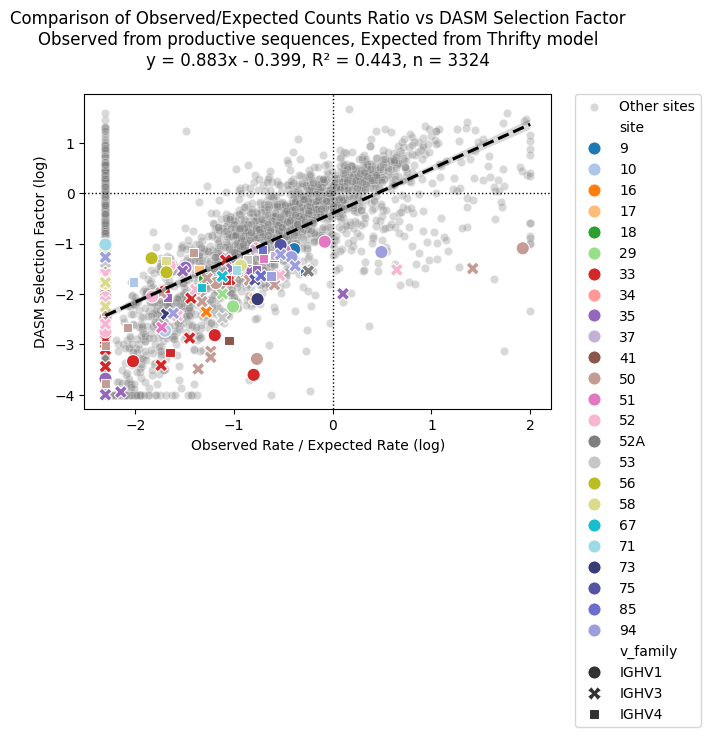

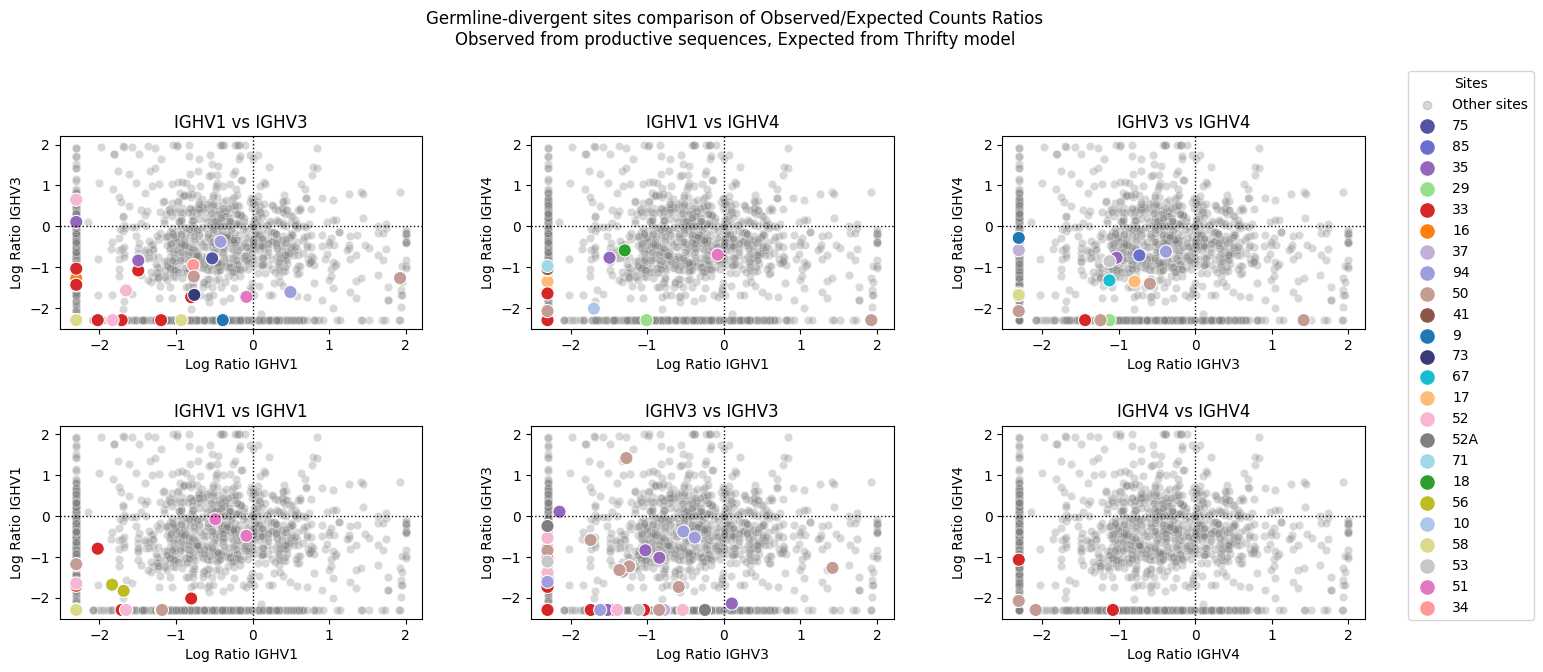

In [ ]:
## show unfiltered data

compare_dasm_rates = pd.merge(merge_counts, dasm_summarized.rename(columns={'selection_factor_target_aa':'child_aa'}), on=['v_family', 'site', 'parent_aa', 'child_aa'], suffixes=('_rates', '_dasm'))
compare_dasm_rates['log_selection_factor'] = np.log(compare_dasm_rates['selection_factor'])

# clip very low and very high values
compare_dasm_rates['log_selection_factor'] = compare_dasm_rates['log_selection_factor'].clip(lower=-4, upper=2)
compare_dasm_rates['log_ratio'] = compare_dasm_rates['log_ratio'].clip(lower=-4, upper=2)

plot_dasm_vs_rates_comparison(compare_dasm_rates, entrenched_sites_aas)
plot_rates_pairwise_analysis(compare_dasm_rates, pairwise_df_dict)

Plotting 83 entrenched points
The following entrenched points were not found in the comparison data:
     site v_family parent_aa child_aa
156    16    IGHV4         G        A
423    29    IGHV4         V        F
558    33    IGHV1         D        A
560    33    IGHV1         D        Y
567    33    IGHV1         S        Y
568    33    IGHV1         T        A
581    33    IGHV3         D        A
582    33    IGHV3         D        G
583    33    IGHV3         D        Y
598    33    IGHV3         T        A
610    33    IGHV4         S        Y
649    35    IGHV1         N        D
657    35    IGHV3         D        G
658    35    IGHV3         D        H
659    35    IGHV3         D        N
712    37    IGHV3         F        V
727    37    IGHV4         V        F
807    41    IGHV1         R        P
987    50    IGHV1         G        W
991    50    IGHV1         L        R
993    50    IGHV1         R        S
994    50    IGHV1         R        W
1007   50    IGHV3       

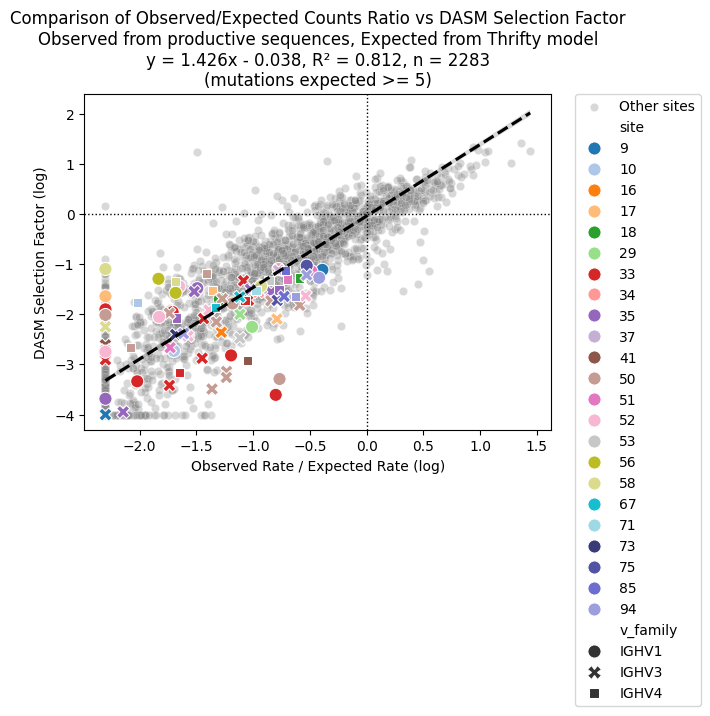

/tmp/ipykernel_280090/3521887936.py:111: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(entrenched_merged_pairwise, x='log_ratio_1', y='log_ratio_2',


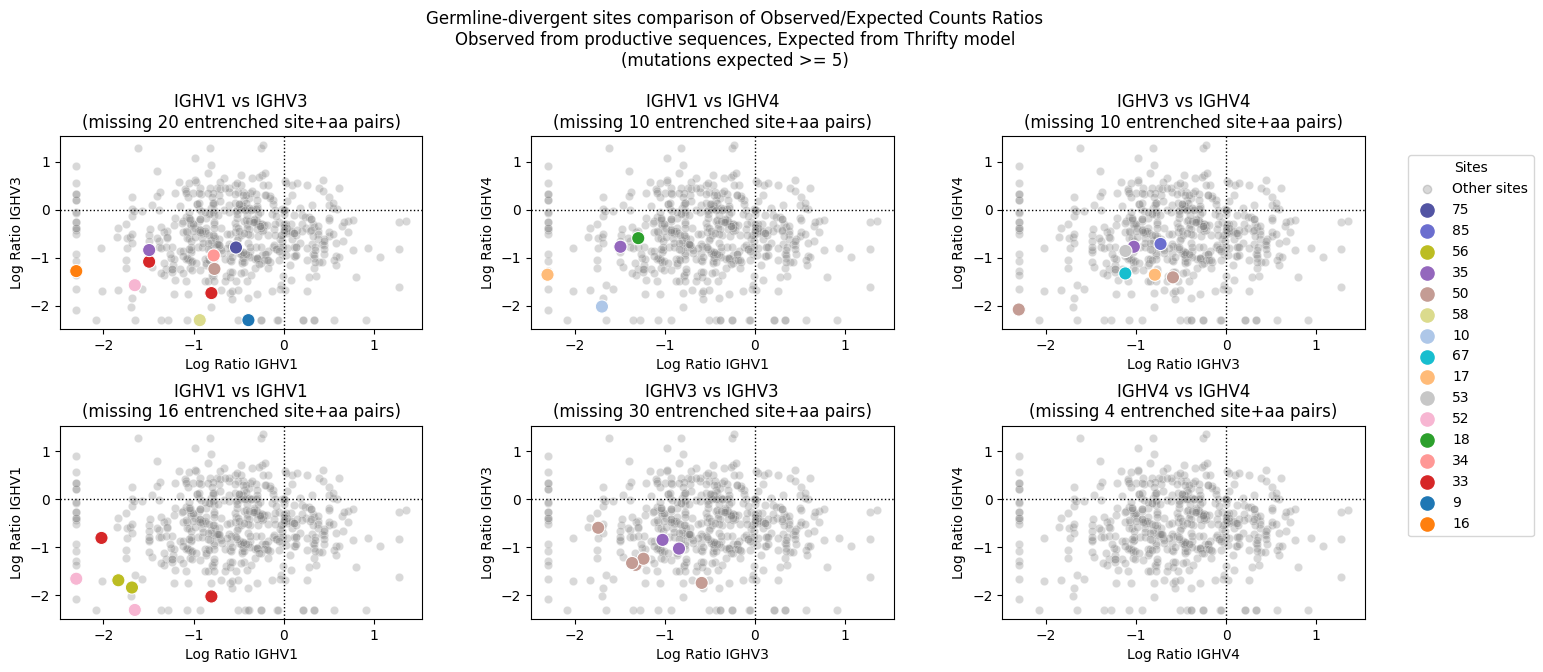

In [ ]:
# show filtered data

compare_dasm_rates = pd.merge(merge_counts, dasm_summarized.rename(columns={'selection_factor_target_aa':'child_aa'}), on=['v_family', 'site', 'parent_aa', 'child_aa'], suffixes=('_rates', '_dasm'))
compare_dasm_rates['log_selection_factor'] = np.log(compare_dasm_rates['selection_factor'])

# clip very low and very high values
compare_dasm_rates['log_selection_factor'] = compare_dasm_rates['log_selection_factor'].clip(lower=-4, upper=2)
compare_dasm_rates['log_ratio'] = compare_dasm_rates['log_ratio'].clip(lower=-4, upper=2)

compare_dasm_rates = compare_dasm_rates[compare_dasm_rates.expected_counts >= 5]

plot_dasm_vs_rates_comparison(compare_dasm_rates, entrenched_sites_aas, title_extra='(mutations expected >= 5)')
plot_rates_pairwise_analysis(compare_dasm_rates, pairwise_df_dict, title_extra='(mutations expected >= 5)')
